##LSTM on Bangla Sentiment


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Load


In [3]:
df = pd.read_csv("/content/drive/MyDrive/The Datasets./Social Media Engagement Dataset.csv")
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,translated_text_content,hashtags,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকা...,#Food,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ...,"#MustHave, #Food",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?...,"#Promo, #Food, #Trending",...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 4:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে ...,"#Reviews, #Sustainable",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো ল...,"#Health, #Travel",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   translated_text_content  12000 non-null  object 
 9   hashtags                 12000 non-null  object 
 10  mentions                 8059 non-null   object 
 11  keywords                 12000 non-null  object 
 12  topic_category           12000 non-null  object 
 13  sentiment_score          12000 non-null  float64
 14  sentiment_label       

In [5]:
selected_columns = ['text_content', 'translated_text_content', 'sentiment_label']
df = df[selected_columns]

In [6]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
Negative,4854
Positive,4839
Neutral,2307


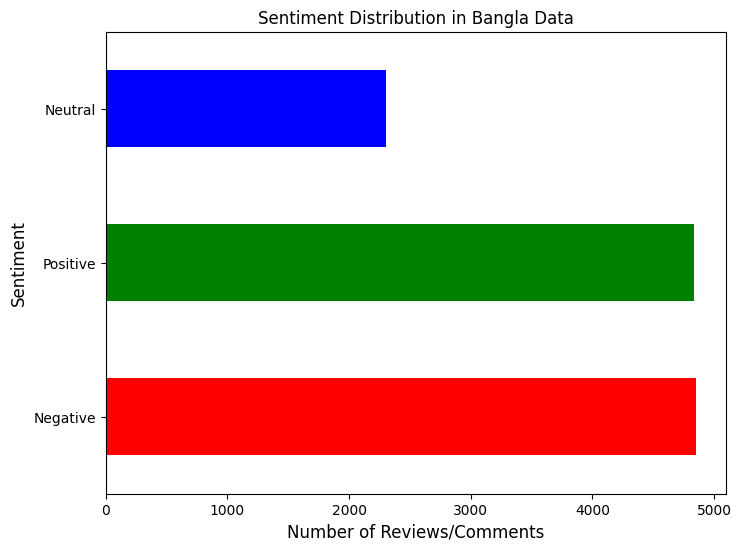

In [7]:
plt.figure(figsize=(8, 6))
df['sentiment_label'].value_counts().plot(kind='barh', color=['red', 'green', 'blue'])
plt.title('Sentiment Distribution in Bangla Data')
plt.xlabel('Number of Reviews/Comments',fontsize=12)
plt.ylabel('Sentiment',fontsize=12)
plt.show()

In [8]:
df.isnull().values.any()

np.False_

In [9]:
df.isnull().sum()

,0
text_content,0
translated_text_content,0
sentiment_label,0


Data Clean

In [10]:
# Word count per sentence
df['word_count'] = df['translated_text_content'].apply(lambda x: len(x.split()))

print(df['word_count'].describe())
print(df['word_count'].min())
print(df['word_count'].max())

count    12000.000000
mean        16.670333
std          2.476691
min          8.000000
25%         15.000000
50%         17.000000
75%         18.000000
max         26.000000
Name: word_count, dtype: float64
8
26


In [11]:
from collections import Counter

all_words = ' '.join(df['translated_text_content']).split()
common = Counter(all_words).most_common(30)
print(common)

[('আপনার', 7969), ('মতামত', 5171), ('জানতে', 4310), ('আমার', 3883), ('আগ্রহী!', 3095), ('সত্যিই', 2861), ('নতুন', 2561), ('অভিজ্ঞতা', 2221), ('শুনতে', 2136), ('সম্পর্কেও', 2130), ('আগ্রহী।', 2130), ('দেখলাম।', 2127), ('করছি।', 2094), ('সম্পর্কে', 1752), ('আমাকে', 1751), ('কি', 1627), ('প্রতিক্রিয়া', 1557), ('থেকে', 1507), ('পেপসি', 1507), ('জানান!', 1408), ('সাথে', 1395), ('সুপারিশ', 1341), ('করে', 1295), ('কেউ', 1277), ('নিয়ে', 1236), ('তা', 1235), ('পর্যালোচনা:', 1228), ('বিজ্ঞাপন', 1216), ('চাই!', 1214), ('আনবক্স', 1210)]


In [12]:
from collections import Counter

words = ' '.join(df['translated_text_content']).split()
word_freq = Counter(words)


rare_words = [w for w, c in word_freq.items() if c == 1]
print("Rare words:", rare_words[:20])


print("Most common:", word_freq.most_common(20))

Rare words: ['টি', '#ট্রেন্ড', 'অ্যালার্ট', '#পরিবেশগত,', '#সেরামূল্য।', 'আইম্যাককে', '#ট্রাভেল।', 'Force', '1', '৮-এ', 'Tundra', 'রিভিউ:', 'React', 'অবশ্যই', 'করব।', 'প্রতিযোগিতায়', 'হবে!', 'প্রোতে', 'সময়কালে', 'এয়ারের']
Most common: [('আপনার', 7969), ('মতামত', 5171), ('জানতে', 4310), ('আমার', 3883), ('আগ্রহী!', 3095), ('সত্যিই', 2861), ('নতুন', 2561), ('অভিজ্ঞতা', 2221), ('শুনতে', 2136), ('সম্পর্কেও', 2130), ('আগ্রহী।', 2130), ('দেখলাম।', 2127), ('করছি।', 2094), ('সম্পর্কে', 1752), ('আমাকে', 1751), ('কি', 1627), ('প্রতিক্রিয়া', 1557), ('থেকে', 1507), ('পেপসি', 1507), ('জানান!', 1408)]


In [13]:
import re
import unicodedata

def clean_bangla_text(text):
    if pd.isnull(text):
        return ""

    text = str(text)

    # Unicode normalize
    text = unicodedata.normalize('NFKC', text)

    # URL remove
    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'#[\u0980-\u09FF\w]+', '', text)


    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Extra spaces remove
    text = re.sub(r'\s+', ' ', text).strip()

    return text



In [14]:
df['clean_text'] = df['translated_text_content'].apply(clean_bangla_text)

In [15]:
pd.set_option('display.max_colwidth', None)
print(df[['translated_text_content', 'clean_text']].head())

                                                                                                 translated_text_content  \
0               গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!   
1  স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।   
2            নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!   
3                                                পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই   
4               টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনার মতামত শুনতে সত্যিই আগ্রহী!   

                                                                                            clean_text  
0                  গুগল থেকে ব্যবহার করে দেখুন সর্বকালের সেরা কেনাকাটা আপনার মতামত শুনতে সত্যিই আগ্রহী  
1  স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সার

In [16]:
pd.set_option('display.max_colwidth', None)

df['clean_text'].loc[1:5]

,clean_text
1,স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম টাকার মূল্য নেই খাওয়া
2,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী আপনার মতামত শুনতে সত্যিই আগ্রহী
3,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ মান নিয়ে হতাশ
4,টয়োটার করোলাটা ট্রাই করলাম সত্যিই খুব ভালো লেগেছে আপনার মতামত শুনতে সত্যিই আগ্রহী
5,নাইকি পাওয়াররিলিজ তো খুবই খারাপ এরপর কী আসছে তা দেখার জন্য অধীর আগ্রহে অপেক্ষা করছি আপনার অভিজ্ঞতা সম্পর্কেও জানতে আগ্রহী


In [17]:
df.head()

,text_content,translated_text_content,sentiment_label,word_count,clean_text
0,Just tried the Chromebook from Google. Best purchase ever. #Food Really interested in hearing your thoughts!,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!,Positive,15,গুগল থেকে ব্যবহার করে দেখুন সর্বকালের সেরা কেনাকাটা আপনার মতামত শুনতে সত্যিই আগ্রহী
1,"Just saw an ad for Microsoft Surface Laptop during the SpringBlast2025. Not worth the money. #MustHave, #Food","স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।",Negative,15,স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম টাকার মূল্য নেই খাওয়া
2,"What's your opinion about Nike's Epic React? #Promo, #Food, #Trending Really interested in hearing your thoughts!","নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!",Negative,15,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী আপনার মতামত শুনতে সত্যিই আগ্রহী
3,"Bummed out with my new Diet Pepsi from Pepsi! Disappointed with the quality. #Reviews, #Sustainable","পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই",Negative,11,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ মান নিয়ে হতাশ
4,"Just tried the Corolla from Toyota. Absolutely loving it. #Health, #Travel Really interested in hearing your thoughts!","টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনার মতামত শুনতে সত্যিই আগ্রহী!",Positive,15,টয়োটার করোলাটা ট্রাই করলাম সত্যিই খুব ভালো লেগেছে আপনার মতামত শুনতে সত্যিই আগ্রহী


Train-test split

In [18]:
from sklearn.model_selection import train_test_split

x = df['clean_text']
y = df['sentiment_label']


x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.15, random_state=42,  stratify=y_train_full)


print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_valid)}")
print(f"Testing set size: {len(x_test)}")



Training set size: 8160
Validation set size: 1440
Testing set size: 2400


Label Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

# Step 1: Label Encoding
y_train_le = le.fit_transform(y_train)
y_valid_le = le.transform(y_valid)
y_test_le  = le.transform(y_test)

# Step 2: One-Hot Encoding
y_train_ohe = to_categorical(y_train_le, num_classes=len(le.classes_))
y_valid_ohe = to_categorical(y_valid_le, num_classes=len(le.classes_))
y_test_ohe  = to_categorical(y_test_le,  num_classes=len(le.classes_))

print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))
print()
print("Example y_train (original):", y_train[:5].values)
print("After Label Encoding:      ", y_train_le[:5])
print("After One-Hot Encoding:\n",   y_train_ohe[:5])

Classes: ['Negative' 'Neutral' 'Positive']
Number of classes: 3

Example y_train (original): ['Neutral' 'Negative' 'Negative' 'Positive' 'Positive']
After Label Encoding:       [1 0 0 2 2]
After One-Hot Encoding:
 [[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


Tokenization and Padding

In [20]:
# Sequence length
lengths = [len(seq) for seq in x_train]

print("Max length:          ", max(lengths))
print("Min length:          ", min(lengths))
print("Mean length:         ", int(np.mean(lengths)))
print("Median length:       ", int(np.median(lengths)))
print("95th percentile:     ", int(np.percentile(lengths, 95)))
print("99th percentile:     ", int(np.percentile(lengths, 99)))

Max length:           152
Min length:           24
Mean length:          93
Median length:        93
95th percentile:      123
99th percentile:      133


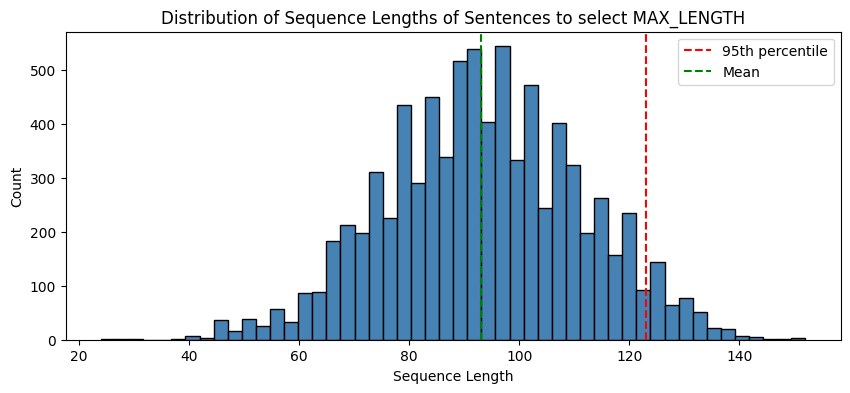

In [21]:
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(int(np.percentile(lengths, 95)), color='red',
            linestyle='--', label='95th percentile')
plt.axvline(int(np.mean(lengths)), color='green',
            linestyle='--', label='Mean')
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Distribution of Sequence Lengths of Sentences to select MAX_LENGTH")
plt.legend()
plt.show()

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization

tokenizer = Tokenizer(num_words=2000, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_valid_seq = tokenizer.texts_to_sequences(x_valid)
x_test_seq  = tokenizer.texts_to_sequences(x_test)


MAX_LEN = 142

x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
x_valid_pad = pad_sequences(x_valid_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
x_test_pad  = pad_sequences(x_test_seq,  maxlen=MAX_LEN, padding='pre', truncating='pre')


print("\nTrain Shape:", x_train_pad.shape)
print("Valid Shape:", x_valid_pad.shape)
print("Test Shape: ", x_test_pad.shape)





Train Shape: (8160, 142)
Valid Shape: (1440, 142)
Test Shape:  (2400, 142)


In [23]:
print("After Tokenization:", x_train_seq[0])
print("After padding:",x_train_pad[0])


After Tokenization: [46, 60, 182, 194, 47, 124, 87, 54, 2, 4, 12, 7, 3]
After padding: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0  46  60 182 194  47 124  87  54   2   4  12   7   3]


In [24]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 712


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 64
LSTM_UNITS = 128
MAX_LEN =142


classes  = np.unique(y_train_le)
weights = compute_class_weight('balanced', classes=classes, y=y_train_le)
class_weights = dict(zip(classes, weights))

print("Calculated class weights:", class_weights)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    x_train_pad, y_train_ohe,
    epochs = 20,
    batch_size = 64,
    validation_data = (x_valid_pad, y_valid_ohe),
    class_weight = class_weights,
    callbacks = [early_stopping],
    verbose = 1
)
model.summary()


Calculated class weights: {np.int64(0): np.float64(0.8239927294759164), np.int64(1): np.float64(1.7335882727852134), np.int64(2): np.float64(0.8267477203647416)}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 55s 387ms/step - accuracy: 0.7760 - loss: 0.5267 - val_accuracy: 0.9243 - val_loss: 0.1903
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 392ms/step - accuracy: 0.9179 - loss: 0.1888 - val_accuracy: 0.9292 - val_loss: 0.1489
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 392ms/step - accuracy: 0.9135 - loss: 0.1979 - val_accuracy: 0.9340 - val_loss: 0.1335
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 82s 397ms/step - accuracy: 0.9312 - loss: 0.1422 - val_accuracy: 0.9299 - val_loss: 0.1248
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 80s 384ms/step - accuracy: 0.9354 - loss: 0.1329 - val_accuracy: 0.9347 - val_loss: 0.1218
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 387ms/step - accuracy: 0.9369 - loss: 0.1252 - val_accuracy: 0.9285 - val_loss: 0.1262
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 81s 382ms/step - accuracy: 0.9379 - loss: 0.1242 - val_accuracy: 0.9382 - val_loss: 0.1158
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 392ms/step - accuracy: 0.9418 - loss: 0.1192 - val

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 142, 64)        │        45,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 142, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,507 (1.66 MB)

 Trainable params: 144,835 (565.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 289,672 (1.11 MB)

In [33]:

# Training Accuracy (Final epoch)

train_acc = history.history['accuracy'][-1]

# Best Validation AccuracY
val_acc = max(history.history['val_accuracy'])

print("\n========== MODEL PERFORMANCE ==========")

print(f"Training Accuracy   : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")


# Test Accuracy (One-hot labels used)

print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test_pad, y_test_ohe, verbose=0)

print(f"Test Accuracy       : {test_acc*100:.2f}%")


========== MODEL PERFORMANCE ==========
Training Accuracy   : 94.40%
Validation Accuracy : 93.82%

Evaluating on Test Data...
Test Accuracy       : 92.79%


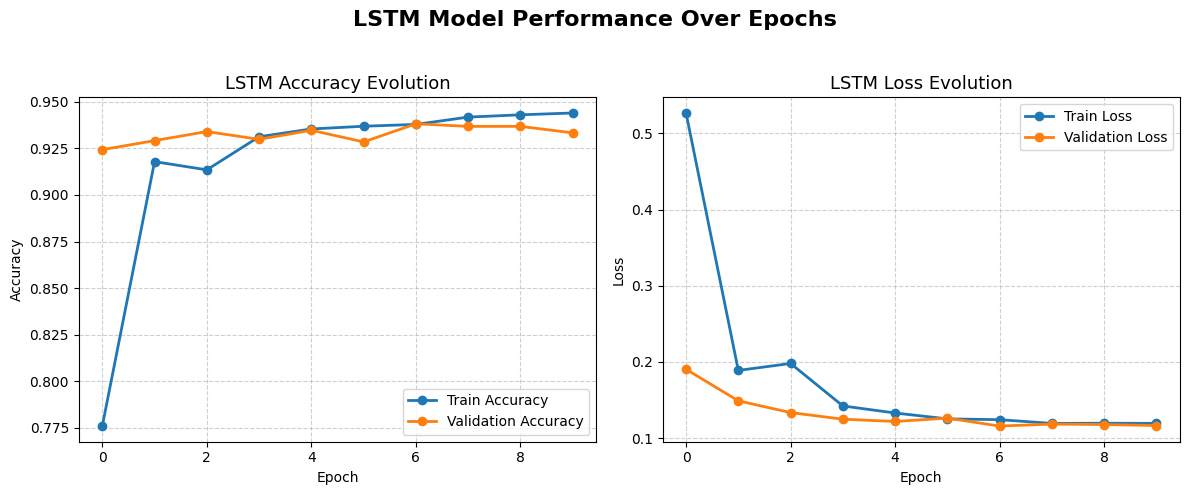

In [31]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,5))

# Overall title
plt.suptitle('LSTM Model Performance Over Epochs', fontsize=16, fontweight='bold')

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=2)
plt.title('LSTM Accuracy Evolution', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
plt.title('LSTM Loss Evolution', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93       971
     Neutral       0.96      0.89      0.92       461
    Positive       0.92      0.94      0.93       968

    accuracy                           0.93      2400
   macro avg       0.93      0.92      0.93      2400
weighted avg       0.93      0.93      0.93      2400



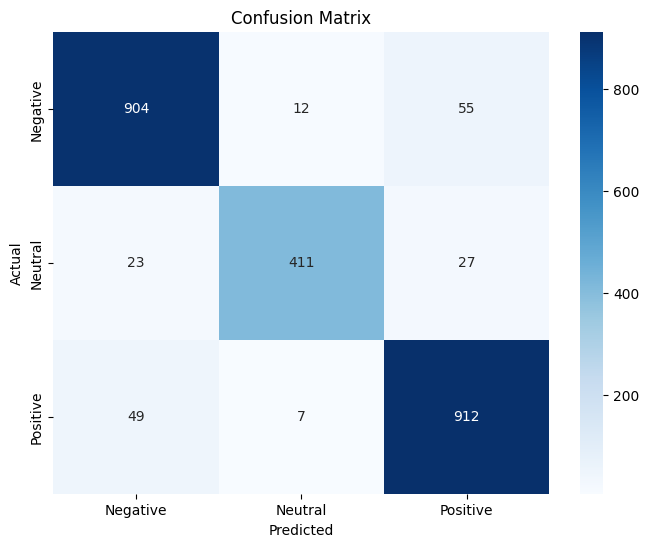

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
y_pred = model.predict(x_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

print("\n--- Classification Report ---")

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()